In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


<Axes: >

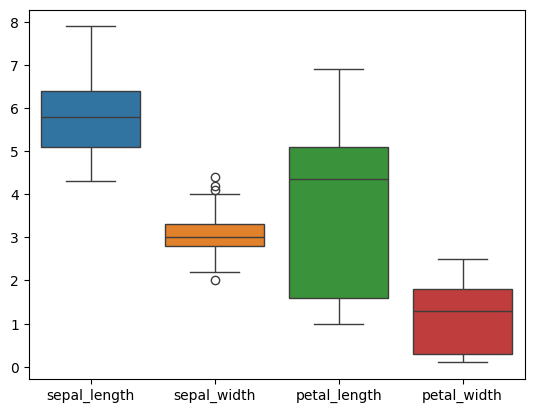

In [4]:
sns.boxplot(data)

In [5]:
X = data.drop('species', axis=1)
y = data['species']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
y_train

22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: species, Length: 120, dtype: str

# 종속변수 y를 label encoder로 변환하기
* 딥러닝에서 다중분류를 할 때 종속변수 y는 대부분 label encoding
* one-hot encoding을 할 경우 메모리 사용량이 많아지기 때문

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [11]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [12]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

# 텐서플로우로 다중분류 분석하기

In [13]:
from keras.models import Sequential
from keras.layers import Dense, Input

2026-03-21 21:59:46.628105: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-21 21:59:46.679330: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-21 21:59:47.746117: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [14]:
len(np.unique(y_train)) # 이 값을 출력층에 집어넣어주면 됨

3

In [15]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(len(np.unique(y_train)), activation='softmax')) # 출력층
model.summary()

I0000 00:00:1774097988.165642  110211 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 560 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

Epoch 1/100


2026-03-21 21:59:50.454563: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c311000c620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-21 21:59:50.454621: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2026-03-21 21:59:50.481205: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-21 21:59:50.629212: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


1/8 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.3750 - loss: 1.1424

I0000 00:00:1774097991.565071  130676 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.3250 - loss: 1.1174 - val_accuracy: 0.3667 - val_loss: 1.0641
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.0615 - val_accuracy: 0.3667 - val_loss: 1.0270
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.0228 - val_accuracy: 0.3667 - val_loss: 0.9937
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3417 - loss: 0.9832 - val_accuracy: 0.4000 - val_loss: 0.9603
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4250 - loss: 0.9516 - val_accuracy: 0.6000 - val_loss: 0.9301
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6167 - loss: 0.9230 - val_accuracy: 0.6667 - val_loss: 0.9049
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.8991 - val_accuracy: 0.7000 - val_loss: 0.8833
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6417 - loss: 0.8760 - val_accuracy: 0.7000 - val_loss: 0.8606
Epoch 

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9500 - loss: 0.3625 - val_accuracy: 0.9667 - val_loss: 0.3524
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.3532 - val_accuracy: 0.9667 - val_loss: 0.3448
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9583 - loss: 0.3469 - val_accuracy: 0.9667 - val_loss: 0.3382
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9667 - loss: 0.3383 - val_accuracy: 0.9667 - val_loss: 0.3303
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9583 - loss: 0.3312 - val_accuracy: 0.9667 - val_loss: 0.3231
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.3231 - val_accuracy: 0.9667 - val_loss: 0.3162
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9833 - loss: 0.3170 - val_accuracy: 0.9667 - val_loss: 0.3115
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9667 - loss: 0.3092 - val_accuracy: 0.9667 - val_loss: 0.3025
Ep

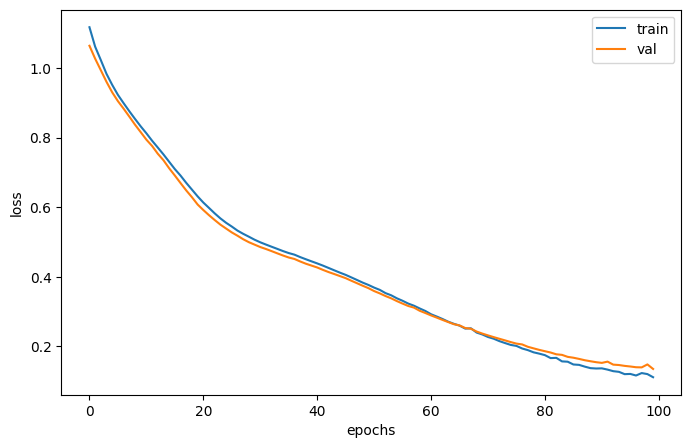

,y_test,pred
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,2
9,1,1


In [16]:
model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))
pred = model.predict(X_test)
print(pred)
pred = pred.argmax(axis=1)
result = pd.DataFrame(dict(y_test = y_test, pred=pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
result

# One-hot Encoding 버전

In [17]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
y_train2

22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: species, Length: 120, dtype: str

In [19]:
y_test2

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
31         Iris-setosa
64     Iris-versicolor
141     Iris-virginica
68     Iris-versicolor
82     Iris-versicolor
110     Iris-virginica
12         Iris-setosa
36         Iris-setosa
9          Iris-setosa
19         Iris-setosa
56     Iris-versicolor
104     Iris-virginica
69     Iris-versicolor
55     Iris-versicolor
132     Iris-virginica
29         Iris-setosa
127     Iris-virginica
26         Iris-setosa
128     Iris-virginica
131     Iris-virginica
145     Iris-virginica
108     Iris-virginica
143     Iris-virginica
45         Iris-setosa
30         Iris-setosa
Name: species, dtype: str

In [20]:
y_train2 = pd.get_dummies(y_train2)
y_train2

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [21]:
y_test2 = pd.get_dummies(y_test2)
y_test2

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [22]:
y_train2.shape[1]

3

In [23]:
from keras.models import Sequential
from keras.layers import Input, Dense

In [24]:
model = Sequential()
model.add(Input(shape=(X_train2.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(y_train2.shape[1], activation='softmax')) # 출력층
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

In [25]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(X_train2, y_train2, epochs=100, batch_size=16,
                   validation_data=(X_test2, y_test2))
pred2 = model.predict(X_test2)
print(pred2)
pred2 = pred2.argmax(axis=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.3417 - loss: 2.5204 - val_accuracy: 0.3000 - val_loss: 2.2112
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3417 - loss: 1.7161 - val_accuracy: 0.3000 - val_loss: 1.4165
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3667 - loss: 1.1850 - val_accuracy: 0.3667 - val_loss: 1.1235
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3500 - loss: 1.1260 - val_accuracy: 0.3667 - val_loss: 1.1148
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3250 - loss: 1.1257 - val_accuracy: 0.3667 - val_loss: 1.1019
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3500 - loss: 1.1139 - val_accuracy: 0.3667 - val_loss: 1.0900
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4167 - loss: 1.1033 - val_accuracy: 0.5333 - val_loss: 1.0790
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5500 - loss: 1.0931 - val_accuracy: 0.6333 - val_loss:

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9417 - loss: 0.6221 - val_accuracy: 0.8667 - val_loss: 0.5987
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8833 - loss: 0.6074 - val_accuracy: 0.8333 - val_loss: 0.5875
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9250 - loss: 0.6007 - val_accuracy: 0.9667 - val_loss: 0.5712
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9167 - loss: 0.5793 - val_accuracy: 0.8667 - val_loss: 0.5588
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9333 - loss: 0.5635 - val_accuracy: 0.9667 - val_loss: 0.5433
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9500 - loss: 0.5569 - val_accuracy: 0.9667 - val_loss: 0.5299
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9250 - loss: 0.5376 - val_accuracy: 0.8667 - val_loss: 0.5206
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9250 - loss: 0.5250 - val_accuracy: 0.9667 - v

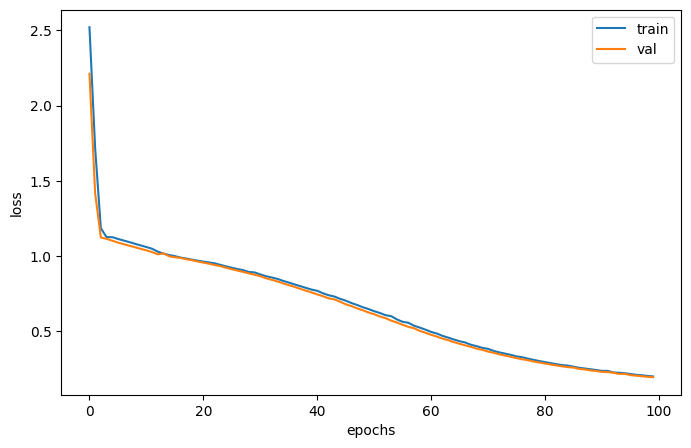

In [26]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()